# Lab 3: KNN, Bayes Classifier and Decision Trees

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
newsgroups = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes') # to remove extra junk
    )
df = pd.DataFrame({
    'text': newsgroups.data,
    'target': newsgroups.target
})

df["category"] = df["target"].map(
    dict(enumerate(newsgroups.target_names))
)

### 1. Loading and exploring data
- (a) How many instances (examples) and variables are in the dataset?

In [39]:
print(df.shape[0])

18846


There are 18846 instances in this dataset, but it has no variables. The dataset is just composed of raw strings just a single entry of text

- (b) (3 points) How many and which classes does the dataset define? What is their share in the
data?

In [40]:
print('Number of classes:', df['category'].nunique())
print('Classes:')
print(df['category'].unique())
print('-------')

classSummary = pd.DataFrame({
    'count': df['category'].value_counts(),
    'share in %': df['category'].value_counts(normalize=True).mul(100).round(2)
})

print(classSummary)

Number of classes: 20
Classes:
<StringArray>
[        'rec.sport.hockey', 'comp.sys.ibm.pc.hardware',
    'talk.politics.mideast',    'comp.sys.mac.hardware',
          'sci.electronics',       'talk.religion.misc',
                'sci.crypt',                  'sci.med',
              'alt.atheism',          'rec.motorcycles',
                'rec.autos',           'comp.windows.x',
            'comp.graphics',                'sci.space',
       'talk.politics.guns',             'misc.forsale',
       'rec.sport.baseball',       'talk.politics.misc',
  'comp.os.ms-windows.misc',   'soc.religion.christian']
Length: 20, dtype: str
-------
                          count  share in %
category                                   
rec.sport.hockey            999        5.30
soc.religion.christian      997        5.29
rec.motorcycles             996        5.28
rec.sport.baseball          994        5.27
sci.crypt                   991        5.26
sci.med                     990        5.25
re

- (c) (5 points) Make a plot showing the class distribution in the dataset

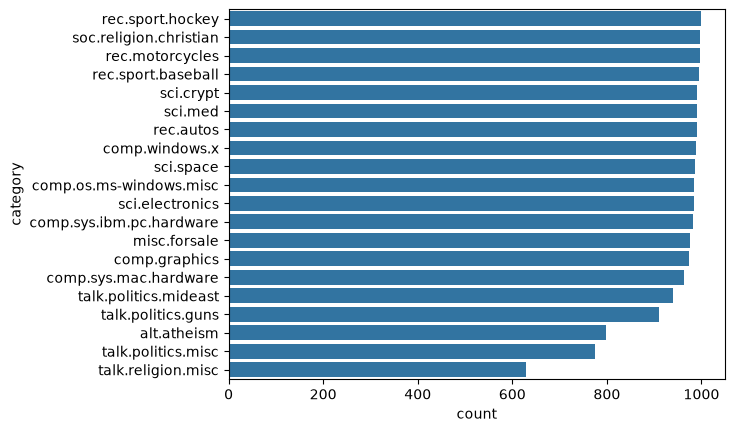

In [41]:
sns.countplot(
    data=df,
    y='category',
    order=df['category'].value_counts().index
    )
plt.show()

- (d) (5 points) Look at a few of the samples. Is there anything in the examples that might cause a classifier to overfit to the training data? How can you fix this? Change the code above accordingly! (You may want to check the documentation of fetch 20newsgroups.)
The header, footer and quotes of every post could cause a classifier to overfit the training data, removing them with the following:
```python
remove=('headers', 'footers', 'quotes')
```
when fetching the dataset. Headers may contain usernames, emails and org names associated with a class, footers may contain repeated signatures and qoutes may repeat text from the message

### 2. Splitting the data into training and test data 
- (a) (5 points) Split the data into a training and test set using 20% of the data for testing, esnuring
class distributions between the training and test data remain the same.

In [42]:
from sklearn.model_selection import train_test_split

dfTrain, dfTest = train_test_split(
    df,
    test_size=0.2,
    random_state=200,
    stratify=df['target']
)
dfTrain = dfTrain.reset_index(drop=True)
dfTest = dfTest.reset_index(drop=True)


- (b) (5 points) Make a plot to check that the class distributions in the test set is the same as for the distribution in the whole data set.

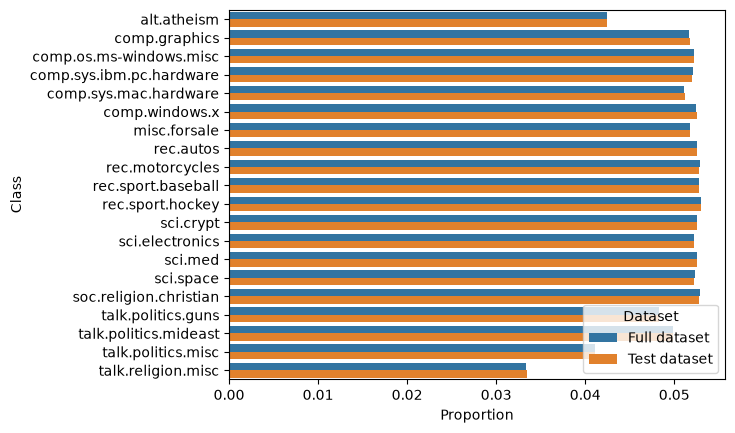

In [43]:
dist = pd.DataFrame({
    "Full dataset": df['category'].value_counts(normalize=True),
    "Test dataset": dfTest['category'].value_counts(normalize=True)
}).reset_index()

dist = dist.rename(columns={'category': 'Class'})
dist = dist.melt(
    id_vars='Class',
    var_name='Dataset',
    value_name='Proportion'
)

sns.barplot(
    data=dist,
    y='Class',
    x='Proportion',
    hue='Dataset'
)
plt.show()

### 3. Feature Engineering / Extraction
The data we are dealing with is basically unstructured text. In order to train a classifier we need to create features from the data to be used as the attributes of the samples. Scikit-learn provides us with some simple feature engineering / extraction for text. To start with we can use a simple Bag
of Words representation, where each text is represented by a vector of integers, each one counting the occurrences of specific words in the text.

In [44]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X_features = vectorizer.fit_transform(dfTrain['text'])

- (a) (5 points) How many attributes do we get from this feature engineering/extraction? Do you think this is a good number? Why (not)?


In [45]:
print('number of attributes', X_features.shape[1])

number of attributes 113584


The CountVectorizer created 113584 attributes. Each attribute is a unique word found in the training documents. This is a pretty large number because there are many different words. This creates a high dimensional and sparse dataset which increases cost of computing and includes unhelpful words.

- (b) (5 points) Change the parameters of CountVectorizer to exclude words appearing in more than
half the instances and words appearing in less than 0.1% of the instances. How many attributes
do you get after that change?

In [46]:
vectorizerFiltered = CountVectorizer(
    max_df=0.5,
    min_df=0.001
)
X_featuresFiltered = vectorizerFiltered.fit_transform(dfTrain['text'])
print('number of attributes', X_featuresFiltered.shape[1])

number of attributes 8865


- (c) (5 points) The output of CountVectorizer is not always very informative. Words that appear often (like ’it’, ’is’, ’has’, etc) tend to have higher values, but contain little information about the topic because they appear in many different documents. We could try weight words higher if
they appear in fewer documents. TfidfTransformer does exactly that. Apply a TfidfTransformer to the output of the CountVectorizer!

In [47]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_featuresFiltered)
print(X_tfidf.shape)

(15076, 8865)


### 4. Training a model and evaluating with cross-validation

* (a) Use scikit-learn’s KNeighborsClassifier to learn a K-nearest Neighbor Classifier from the training data.

In [48]:
from sklearn.neighbors import KNeighborsClassifier

knc = KNeighborsClassifier()

knc.fit(
    X_tfidf,
    dfTrain["target"]
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](20,)","[ 0, 1, 2,...,17,18,19]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


* (b) How many neighbors does the classifier use?

In [49]:
print("Number of neighbors: ", knc.n_neighbors)

Number of neighbors:  5


* (c) Use 5-fold cross-validation to estimate the models accuracy on both training and
validation set. (It might be easiest to use sklearn.model_selection cross_validate() for this).

In [50]:
from sklearn.model_selection import cross_validate

result = cross_validate(
    knc,
    X_tfidf,
    dfTrain["target"],
    cv=5,
    scoring="accuracy",
    return_train_score=True
)

print("Validation Accuracy Mean: ", result["test_score"].mean())
print("Training Accuracy Mean: ", result["train_score"].mean())

Validation Accuracy Mean:  0.10692488046064988
Training Accuracy Mean:  0.37024085552944447


* (d) What do the numbers tell you about overfitting/underfitting of the model?

We can see from the output that the model scores very low on the validation set, and scores somewhat low on the training set. This indicates that it's underfitting.

* (e) Replace the KNN classifier with a Naive-Bayes classifier (MultinomialNB) and measure its accuracy using cross-validation. How well does this model perform in comparision?

In [51]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()

result = cross_validate(
    mnb,
    X_tfidf,
    dfTrain["target"],
    cv=5,
    scoring="accuracy",
    return_train_score=True
)

print("Validation Accuracy Mean: ", result["test_score"].mean())
print("Training Accuracy Mean: ", result["train_score"].mean())

Validation Accuracy Mean:  0.6893071996340139
Training Accuracy Mean:  0.8037112093128587


Using the Naive-Bayes classifiers instead of kNN classifier results in a much higher accuracy for the validation- and training sets, indicating good fitting.

### 5. Pipeline and Hyperparameter-Tuning
Both preprocessing steps, as well as the classifier have hyper-parameters that could be tuned to get a better model. This is easiest to do, if we put all of these steps together in a pipeline that can be treated as an estimator without having to run each individual step when testing different parameter values.

* (a) Pick a classifier (KNN Classifier, Naive-Bayes, decision tree, or something else that you tried before). Put all the preprocessing steps and the classifier into a pipeline.

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("tfidf", TfidfTransformer()),
    ("classifier", MultinomialNB())
])

(b) Select 1 or 2 hyperparameters for each step in the pipeline that you find most important for the task. Select around 3 reasonable values for each hyper-parameter (2 in case of non-numeric hyperparameters that only have two options) and setup a search for the best combination of hyper-parameter values in the pipeline. This can be done for example using GridSearchCV or RandomizedSearchCV (see the user guide on grid search). Note: When setting this up, think about the potential run-time of the search. For each tested parameter combination, the search will do cross-validation. Think about how many combinations of values you want to test and how long it takes run the pipeline once before running this, otherwise you might be surprised about the run-time.

In [53]:
params = {
    "vectorizer__max_df": [0.5, 0.75, 1.0],
    "vectorizer__min_df": [0.0005, 0.001, 0.005],
    "classifier__alpha": [0.1, 1.0, 10.0] 
}

search = GridSearchCV(
    pipeline,
    params,
    cv=5,
    scoring="accuracy",
    return_train_score=True
)

search.fit(dfTrain["text"], dfTrain["target"])

print(search.best_params_)
print(search.best_score_)

{'classifier__alpha': 0.1, 'vectorizer__max_df': 0.5, 'vectorizer__min_df': 0.0005}
0.7361371304397553


(c) Report on the results. Which parameter combination is best? How good is it? Does that model still suffer from overfitting?

The best combination the 

(d) Analyze the results of the search in more detail. Which of the tuned parameters seems to have the most influence on performance of the model (reducing overfitting or underfitting)? Which parameters are independent/dependent on each other? (the independent ones could have been tuned separately)

In [54]:
results = pd.DataFrame(search.cv_results_)

# Compare the average validation score for each value of each tuned parameter.
parameter_columns = [
    "param_vectorizer__max_df",
    "param_vectorizer__min_df",
    "param_classifier__alpha"
]

for parameter in parameter_columns:
    summary = (
        results.groupby(parameter, observed=True)["mean_test_score"]
        .agg(["mean", "std", "min", "max"])
        .sort_values("mean", ascending=False)
    )
    print(f"\n{parameter}")
    print(summary)

# Show how max_df and min_df interact while alpha is fixed at its best value.
best_alpha = search.best_params_["classifier__alpha"]
interaction = results[
    results["param_classifier__alpha"] == best_alpha
].pivot(
    index="param_vectorizer__min_df",
    columns="param_vectorizer__max_df",
    values="mean_test_score"
)

print(f"\nValidation accuracy by min_df and max_df when alpha={best_alpha}:")
print(interaction.round(4))

# Compare training and validation scores for the best configuration.
best_row = results.loc[results["rank_test_score"].idxmin()]
print("\nBest configuration:")
print(search.best_params_)
print("Mean training accuracy:", round(best_row["mean_train_score"], 4))
print("Mean validation accuracy:", round(best_row["mean_test_score"], 4))
print("Train-validation gap:", round(
    best_row["mean_train_score"] - best_row["mean_test_score"], 4
))


param_vectorizer__max_df
                              mean       std       min       max
param_vectorizer__max_df                                        
0.50                      0.644615  0.067660  0.549084  0.736137
0.75                      0.626441  0.087637  0.513863  0.735407
1.00                      0.621105  0.093810  0.496086  0.735142

param_vectorizer__min_df
                              mean       std       min       max
param_vectorizer__min_df                                        
0.0005                    0.650128  0.096024  0.496086  0.736137
0.0010                    0.646605  0.084705  0.510015  0.719289
0.0050                    0.595427  0.053812  0.509087  0.636442

param_classifier__alpha
                             mean       std       min       max
param_classifier__alpha                                        
0.1                      0.696876  0.046229  0.635646  0.736137
1.0                      0.664566  0.029962  0.623507  0.691894
10.0             

(e) Try out other preprocessing steps, other hyper-parameters and other models (e.g.,TfidfVectorizer or MultinomialNB). What is the best model you can come up with?

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", KNeighborsClassifier())
])

params = {
    "vectorizer__max_df": [0.5, 0.75, 1.0],
    "vectorizer__min_df": [0.0005, 0.001, 0.005],
    "classifier__n_neighbors": [3, 5, 10]
}

search = GridSearchCV(
    pipeline,
    params,
    cv=5,
    scoring="accuracy",
    return_train_score=True
)

search.fit(dfTrain["text"], dfTrain["target"])

results = pd.DataFrame(search.cv_results_)

# Compare the average validation score for each value of each tuned parameter.
parameter_columns = [
    "param_vectorizer__max_df",
    "param_vectorizer__min_df",
    "param_classifier__n_neighbors"
]

for parameter in parameter_columns:
    summary = (
        results.groupby(parameter, observed=True)["mean_test_score"]
        .agg(["mean", "std", "min", "max"])
        .sort_values("mean", ascending=False)
    )
    print(f"\n{parameter}")
    print(summary)

# Show how max_df and min_df interact while n_neighbors is fixed at its best value.
best_n_neighbors = search.best_params_["classifier__n_neighbors"]
interaction = results[
    results["param_classifier__n_neighbors"] == best_n_neighbors
].pivot(
    index="param_vectorizer__min_df",
    columns="param_vectorizer__max_df",
    values="mean_test_score"
)

print(f"\nValidation accuracy by min_df and max_df when n_neighbors={best_n_neighbors}:")
print(interaction.round(4))

# Compare training and validation scores for the best configuration.
best_row = results.loc[results["rank_test_score"].idxmin()]
print("\nBest configuration:")
print(search.best_params_)
print("Mean training accuracy:", round(best_row["mean_train_score"], 4))
print("Mean validation accuracy:", round(best_row["mean_test_score"], 4))
print("Train-validation gap:", round(
    best_row["mean_train_score"] - best_row["mean_test_score"], 4
))


param_vectorizer__max_df
                              mean       std       min       max
param_vectorizer__max_df                                        
0.50                      0.206104  0.004075  0.198527  0.212191
0.75                      0.196619  0.006475  0.186124  0.204696
1.00                      0.189337  0.007520  0.176174  0.200119

param_vectorizer__min_df
                              mean       std       min       max
param_vectorizer__min_df                                        
0.0010                    0.200259  0.008729  0.186522  0.212191
0.0005                    0.199707  0.006840  0.189838  0.209870
0.0050                    0.192094  0.010212  0.176174  0.205227

param_classifier__n_neighbors
                                   mean       std       min       max
param_classifier__n_neighbors                                        
10                             0.202610  0.006458  0.190634  0.212191
5                              0.196154  0.009810  0.1818